# Tripadvisor Reviews Analysis
### Authors: Erez, Hilla & Eitan
### Date: 2026-03

# Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Data Load

In [98]:
df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")
df.head()

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_23780\874356342.py:1: DtypeWarning: Columns (0: region) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/tripadvisor_european_restaurants.csv")


,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
0,g10001637-d10002227,Le 147,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"10 Maison Neuve, 87510 Saint-Jouvent France",45.961674,1.169131,...,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0,NaN,NaN
1,g10001637-d14975787,Le Saint Jouvent,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Ha...",France,Nouvelle-Aquitaine,Haute-Vienne,Saint-Jouvent,"16 Place de l Eglise, 87510 Saint-Jouvent France",45.957040,1.205480,...,2.0,2.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2,g10002858-d4586832,Au Bout du Pont,"[""Europe"", ""France"", ""Centre-Val de Loire"", ""B...",France,Centre-Val de Loire,Berry,Rivarennes,"2 rue des Dames, 36800 Rivarennes France",46.635895,1.386133,...,3.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
3,g10002986-d3510044,Le Relais de Naiade,"[""Europe"", ""France"", ""Nouvelle-Aquitaine"", ""Co...",France,Nouvelle-Aquitaine,Correze,Lacelle,"9 avenue Porte de la Correze 19170, 19170 Lace...",45.642610,1.824460,...,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN
4,g10022428-d9767191,Relais Du MontSeigne,"[""Europe"", ""France"", ""Occitanie"", ""Aveyron"", ""...",France,Occitanie,Aveyron,Saint-Laurent-de-Levezou,"route du Montseigne, 12620 Saint-Laurent-de-Le...",44.208860,2.960470,...,4.0,7.0,0.0,0.0,0.0,4.5,4.5,4.5,NaN,NaN


# Basic info

In [14]:
df

,restaurant_link,country,city,claimed,price_level,meals,cuisines,vegetarian_friendly,vegan_options,gluten_free,...,total_reviews_count,default_language,excellent,very_good,average,poor,terrible,food,service,value
0,g10001637-d10002227,France,Saint-Jouvent,Claimed,€,"Lunch, Dinner",French,N,N,N,...,36.0,English,2.0,0.0,0.0,0.0,0.0,4.0,4.5,4.0
3,g10002986-d3510044,France,Lacelle,Claimed,€,"Lunch, Dinner",French,N,N,N,...,34.0,English,1.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5
5,g10029260-d6605477,France,Le Crozet,Claimed,€€-€€€,"Lunch, Dinner, Drinks",French,N,N,N,...,64.0,All languages,44.0,15.0,2.0,2.0,1.0,4.5,4.5,4.5
6,g10029907-d17781655,France,Saint-Denis,Claimed,€€-€€€,"Lunch, Dinner","French, European",N,N,N,...,24.0,English,4.0,0.0,0.0,0.0,0.0,4.5,4.5,4.5
7,g10029907-d8079764,France,Saint-Denis,Claimed,€€-€€€,NaN,"French, European",Y,N,N,...,133.0,English,9.0,3.0,1.0,0.0,0.0,4.5,4.5,4.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083384,g946544-d14997416,Romania,Rasnov,Claimed,€,NaN,"European, Eastern European, Central European, ...",Y,Y,N,...,83.0,English,54.0,7.0,4.0,3.0,1.0,5.0,4.5,5.0
1083387,g946544-d4753627,Romania,Rasnov,Unclaimed,€€-€€€,NaN,"European, Romanian, Eastern European",N,N,N,...,61.0,English,7.0,13.0,8.0,6.0,9.0,3.5,3.0,3.5
1083388,g946544-d7128597,Romania,Rasnov,Claimed,€€-€€€,"Breakfast, Lunch, Dinner, Brunch",Romanian,Y,Y,Y,...,355.0,English,159.0,48.0,25.0,11.0,23.0,4.5,4.0,4.5
1083389,g946544-d8490226,Romania,Rasnov,Unclaimed,€€-€€€,"Lunch, Brunch","Fast food, European",N,N,N,...,21.0,English,3.0,7.0,4.0,3.0,2.0,4.0,4.5,4.0


In [13]:
df.columns

Index(['restaurant_link', 'country', 'city', 'claimed', 'price_level', 'meals',
       'cuisines', 'vegetarian_friendly', 'vegan_options', 'gluten_free',
       'open_days_per_week', 'open_hours_per_week', 'working_shifts_per_week',
       'avg_rating', 'total_reviews_count', 'default_language', 'excellent',
       'very_good', 'average', 'poor', 'terrible', 'food', 'service', 'value'],
      dtype='str')

In [6]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1083397 entries, 0 to 1083396
Data columns (total 42 columns):
 #   Column                             Non-Null Count    Dtype  
---  ------                             --------------    -----  
 0   restaurant_link                    1083397 non-null  str    
 1   restaurant_name                    1083396 non-null  str    
 2   original_location                  1083397 non-null  str    
 3   country                            1083397 non-null  str    
 4   region                             1033074 non-null  str    
 5   province                           742765 non-null   str    
 6   city                               682712 non-null   str    
 7   address                            1083397 non-null  str    
 8   latitude                           1067607 non-null  float64
 9   longitude                          1067607 non-null  float64
 10  claimed                            1081555 non-null  str    
 11  awards                             

,latitude,longitude,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,reviews_count_in_default_language,excellent,very_good,average,poor,terrible,food,service,value,atmosphere
count,1.067607e+06,1.067607e+06,593832.000000,593832.000000,593832.000000,986761.000000,1.031162e+06,988204.000000,988204.000000,988204.000000,988204.000000,988204.000000,988204.000000,599325.000000,604287.000000,602692.000000,261785.000000
mean,4.656718e+01,5.838040e+00,6.327081,62.023282,7.630754,4.035943,1.028890e+02,44.563415,24.653440,10.490516,4.109302,2.355306,2.954850,4.104179,4.067245,3.982897,3.933682
std,5.882611e+00,8.639410e+00,0.966734,30.538134,2.550128,0.713694,2.672415e+02,148.728179,89.850801,35.512256,15.669631,9.352756,11.030069,0.564208,0.581267,0.577605,0.555262
min,2.764031e+01,-7.121809e+01,1.000000,0.000000,1.000000,1.000000,0.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,4.190986e+01,-8.027315e-01,6.000000,39.000000,6.000000,3.500000,6.000000e+00,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,4.000000,4.000000,3.500000,3.500000
50%,4.658510e+01,5.646530e+00,7.000000,58.500000,7.000000,4.000000,2.400000e+01,7.000000,3.000000,2.000000,1.000000,0.000000,0.000000,4.000000,4.000000,4.000000,4.000000
75%,5.140537e+01,1.223767e+01,7.000000,81.500000,7.000000,4.500000,9.300000e+01,26.000000,13.000000,6.000000,2.000000,1.000000,2.000000,4.500000,4.500000,4.500000,4.500000
max,6.994156e+01,3.336942e+01,7.000000,168.000000,15.000000,5.000000,5.240400e+04,15229.000000,9383.000000,4091.000000,2132.000000,1253.000000,1215.000000,5.000000,5.000000,5.000000,5.000000


## Filling some NA (city)

In [99]:
# Ensure the 'original_location' column contains lists and 'city' exists
df['city'] = df.apply(lambda row: row['original_location'][3] if pd.isnull(row['city']) and len(row['original_location']) > 3 else row['city'], axis=1)

## dropping columns

In [100]:
cols_to_drop = [
    "keywords", "atmosphere", "awards", "price_range", "features",
    "special_diets", "reviews_count_in_default_language",
    "latitude", "longitude", "original_location", "region",
    "province", "address", "restaurant_name",
    "original_open_hours", "top_tags",
    "popularity_detailed", "popularity_generic"
]

df = df.drop(columns=cols_to_drop)

## droping rows

In [102]:
df = df.dropna(subset=["avg_rating"])

### total_reviews_count >20

In [103]:
df = df[df["total_reviews_count"] >= 20]

## prepering data: y=1, n=0

In [104]:
df[["vegetarian_friendly", "vegan_options", "gluten_free"]] = df[["vegetarian_friendly", "vegan_options", "gluten_free"]].replace({"Y": 1, "N": 0})

!!!!!!!!!ADD this !!!!!!!!!

In [105]:
df["claimed"] = df["claimed"].map({
    "Unclaimed": 0,
    "Claimed": 1
})

In [106]:
df["price_level"] = df["price_level"].map({
    "€": "low",
    "€€-€€€": "medium",
    "€€€€": "high"
})

In [107]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 559090 entries, 0 to 1083390
Data columns (total 24 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   restaurant_link          559090 non-null  str    
 1   country                  559090 non-null  str    
 2   city                     559090 non-null  str    
 3   claimed                  558144 non-null  float64
 4   price_level              553184 non-null  str    
 5   meals                    405046 non-null  str    
 6   cuisines                 534238 non-null  str    
 7   vegetarian_friendly      559090 non-null  object 
 8   vegan_options            559090 non-null  object 
 9   gluten_free              559090 non-null  object 
 10  open_days_per_week       395642 non-null  float64
 11  open_hours_per_week      395642 non-null  float64
 12  working_shifts_per_week  395642 non-null  float64
 13  avg_rating               559090 non-null  float64
 14  total_reviews_count

,claimed,open_days_per_week,open_hours_per_week,working_shifts_per_week,avg_rating,total_reviews_count,excellent,very_good,average,poor,terrible,food,service,value
count,558144.000000,395642.000000,395642.000000,395642.000000,559090.000000,559090.000000,559090.000000,559090.000000,559090.000000,559090.000000,559090.000000,534152.000000,536338.000000,535772.000000
mean,0.642207,6.348176,60.992056,7.872304,4.034913,184.269155,41.550255,17.604776,6.885723,3.955848,4.831855,4.109318,4.068573,3.977848
std,0.479351,0.947795,30.761155,2.654934,0.566664,342.385539,116.583688,45.920485,20.377221,12.174509,14.335076,0.546283,0.563752,0.560102
min,0.000000,1.000000,0.000000,1.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,6.000000,37.500000,6.000000,3.500000,39.000000,2.000000,1.000000,0.000000,0.000000,0.000000,4.000000,4.000000,3.500000
50%,1.000000,7.000000,56.000000,7.000000,4.000000,82.000000,9.000000,5.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.000000
75%,1.000000,7.000000,80.500000,9.000000,4.500000,201.000000,31.000000,15.000000,5.000000,3.000000,4.000000,4.500000,4.500000,4.500000
max,1.000000,7.000000,168.000000,15.000000,5.000000,52404.000000,9383.000000,4091.000000,2132.000000,1253.000000,1215.000000,5.000000,5.000000,5.000000


In [ ]:
df

# Working with NA

In [108]:
na_counts = df.isna().sum()
print(na_counts)

restaurant_link                 0
country                         0
city                            0
claimed                       946
price_level                  5906
meals                      154044
cuisines                    24852
vegetarian_friendly             0
vegan_options                   0
gluten_free                     0
open_days_per_week         163448
open_hours_per_week        163448
working_shifts_per_week    163448
avg_rating                      0
total_reviews_count             0
default_language                0
excellent                       0
very_good                       0
average                         0
poor                            0
terrible                        0
food                        24938
service                     22752
value                       23318
dtype: int64


In [109]:
na_percentage = (df.isna().sum() / len(df)) * 100
print(na_percentage)

restaurant_link             0.000000
country                     0.000000
city                        0.000000
claimed                     0.169204
price_level                 1.056359
meals                      27.552630
cuisines                    4.445080
vegetarian_friendly         0.000000
vegan_options               0.000000
gluten_free                 0.000000
open_days_per_week         29.234649
open_hours_per_week        29.234649
working_shifts_per_week    29.234649
avg_rating                  0.000000
total_reviews_count         0.000000
default_language            0.000000
excellent                   0.000000
very_good                   0.000000
average                     0.000000
poor                        0.000000
terrible                    0.000000
food                        4.460463
service                     4.069470
value                       4.170706
dtype: float64


## Droping/keeping or transforming

In [ ]:
claimed
price_level

### Droping (High missing)

In [24]:
high_missing_cols = [
    'meals',
    'open_days_per_week',
    'open_hours_per_week',
    'working_shifts_per_week'
]

df = df.drop(columns=high_missing_cols)

In [ ]:
df

## check for MCAR, MAR or MNAR

<Axes: >

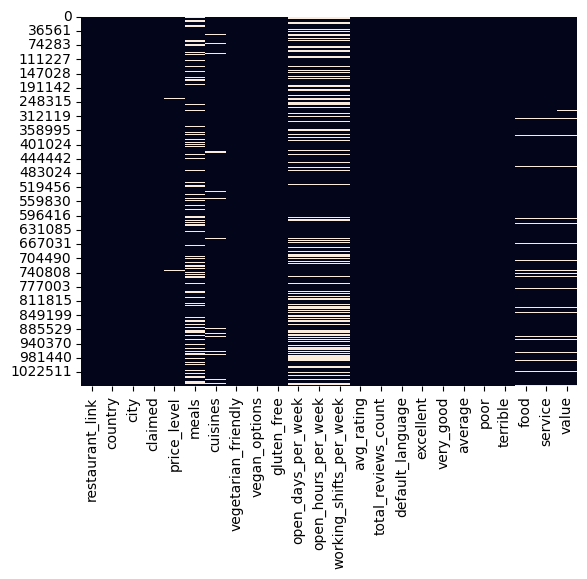

In [110]:
sns.heatmap(df.isna(), cbar=False)

In [111]:
# keep only columns that have at least one NA
df_na = df.loc[:, df.isna().any()]
df_na.isna().corr()

,claimed,price_level,meals,cuisines,open_days_per_week,open_hours_per_week,working_shifts_per_week,food,service,value
claimed,1.000000,-0.001700,0.066758,0.190879,-0.000819,-0.000819,-0.000819,0.190535,0.199886,0.197341
price_level,-0.001700,1.000000,-0.003848,0.032553,0.058289,0.058289,0.058289,0.236329,0.230279,0.229864
meals,0.066758,-0.003848,1.000000,0.117067,-0.063075,-0.063075,-0.063075,0.028041,0.024501,0.024296
cuisines,0.190879,0.032553,0.117067,1.000000,0.053075,0.053075,0.053075,0.064217,0.056164,0.056239
open_days_per_week,-0.000819,0.058289,-0.063075,0.053075,1.000000,1.000000,1.000000,0.050127,0.044672,0.045852
open_hours_per_week,-0.000819,0.058289,-0.063075,0.053075,1.000000,1.000000,1.000000,0.050127,0.044672,0.045852
working_shifts_per_week,-0.000819,0.058289,-0.063075,0.053075,1.000000,1.000000,1.000000,0.050127,0.044672,0.045852
food,0.190535,0.236329,0.028041,0.064217,0.050127,0.050127,0.050127,1.000000,0.936949,0.939681
service,0.199886,0.230279,0.024501,0.056164,0.044672,0.044672,0.044672,0.936949,1.000000,0.968068
value,0.197341,0.229864,0.024296,0.056239,0.045852,0.045852,0.045852,0.939681,0.968068,1.000000


## Spliting - managing NA

!!! Add this !!!

In [112]:
# 1. Feature engineering FIRST
for col in ["food", "service", "value"]:
    df[col + "_missing"] = df[col].isna().astype(int)

df["open_info_missing"] = df["open_days_per_week"].isna().astype(int)

In [113]:
df["great_restaurant"] = df["avg_rating"] > 4

In [114]:
df['great_restaurant'].value_counts(normalize=True) * 100

great_restaurant
False    60.278131
True     39.721869
Name: proportion, dtype: float64

In [115]:
X = df.drop(columns=['great_restaurant'])  # example target
y = df['great_restaurant']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=55)

# imputations

## A. Simple imputation (low missing)

In [116]:
simple_imputer = SimpleImputer(strategy="most_frequent")  # for categorical

claimed

price_level

## B. KNN imputation (moderate missing, numeric)
food, service, value (make into one? use as predictors?)

In [ ]:
knn_imputer = KNNImputer(n_neighbors=5) #not in use

## C. High-missing features (be careful)
meals, open_*
Very high missing (~27–29%)

meals, open_days_per_week, open_hours_per_week, working_shifts_per_week
→ KNN can struggle here (too sparse), and these variables are also highly redundant (open_* are perfectly correlated).

In [117]:
df[["open_days_per_week", "open_hours_per_week", "working_shifts_per_week"]].corr()

,open_days_per_week,open_hours_per_week,working_shifts_per_week
open_days_per_week,1.000000,0.503751,0.344099
open_hours_per_week,0.503751,1.000000,-0.125107
working_shifts_per_week,0.344099,-0.125107,1.000000


If they are NOT strongly correlated in values:

Keep all three, but:

Add ONE shared missing indicator:
df["open_info_missing"] = df["open_days_per_week"].isna().astype(int)
Impute simply (median)

👉 Still avoid KNN here — too many missing values (~29%)

In [118]:
df["open_info_missing"] = df["open_days_per_week"].isna().astype(int)

## Pipeline

In [121]:
num_cols = [
    "food", "service", "value",
    "open_days_per_week",
    "open_hours_per_week",
    "working_shifts_per_week"
]
cat_cols = ["meals", "claimed", "price_level"]
indicator_cols = [
    "food_missing", "service_missing", "value_missing",
    "open_info_missing"
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
    ("indicators", "passthrough", indicator_cols)
])

Fit ONLY on train, apply to test

In [122]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [125]:
# Convert to DataFrame
df_check = pd.DataFrame(X_train_processed, columns=preprocessor.get_feature_names_out())

# 1. Verify No Missing Values
print(df_check.isnull().sum())

# 2. Verify Scaling (Mean should be ~0, Std should be ~1 for numeric cols)
print(df_check.filter(like='num__').describe().round(2))

num__food                        0
num__service                     0
num__value                       0
num__open_days_per_week          0
num__open_hours_per_week         0
num__working_shifts_per_week     0
cat__meals                       0
cat__claimed                     0
cat__price_level                 0
indicators__food_missing         0
indicators__service_missing      0
indicators__value_missing        0
indicators__open_info_missing    0
dtype: int64
        num__food  num__service  num__value  num__open_days_per_week  \
count    447272.0     447272.00   447272.00                447272.00   
unique        9.0          9.00        9.00                     7.00   
top          -0.2         -0.12        0.04                     0.54   
freq     162965.0     165466.00   177857.00                306777.00   

        num__open_hours_per_week  num__working_shifts_per_week  
count                  447272.00                     447272.00  
unique                   2408.00         

# Different tests

## splitting and adding variables

In [26]:
df['cuisines_list'] = df['cuisines'].str.split(', ')
df['cuisines_list'] = df['cuisines'].str.split(r',\s*')
df['cuisines_list'] = (
    df['cuisines']
    .str.lower()
    .str.split(r',\s*')
)
df['cuisines_list'] = df['cuisines_list'].apply(
    lambda lst: [c.strip() for c in lst] if isinstance(lst, list) else lst
)

cuisine_map = {
    # Italian group
    'pizza': 'italian',
    'mediterranean': 'italian',

    # Cafe group
    'café': 'cafe',
    'coffee': 'cafe',

    # Fast food group
    'fast food': 'fast_food',
    'street food': 'fast_food',

    # Bar/pub group
    'pub': 'bar',
    'gastropub': 'bar',

    # European generalization
    'french': 'european',
    'spanish': 'european',
    'german': 'european',
    'british': 'european'
}

def clean_cuisines(lst):
    if not isinstance(lst, list):
        return lst
    return list(set([cuisine_map.get(c, c) for c in lst]))

df['cuisines_clean'] = df['cuisines_list'].apply(clean_cuisines)


exploded = df.explode('cuisines_clean')

top10 = (
    exploded['cuisines_clean']
    .value_counts()
    .head(10)
    .index
    .tolist()
)

In [27]:
#top 10
for cuisine in top10:
    df[f"is_{cuisine}"] = df['cuisines_clean'].apply(
        lambda x: cuisine in x if isinstance(x, list) else False
    )
# other
df['is_other'] = df['cuisines_clean'].apply(
    lambda x: any(c not in top10 for c in x) if isinstance(x, list) else False
)

C:\Users\Psychologist\AppData\Local\Temp\ipykernel_26716\1685762949.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


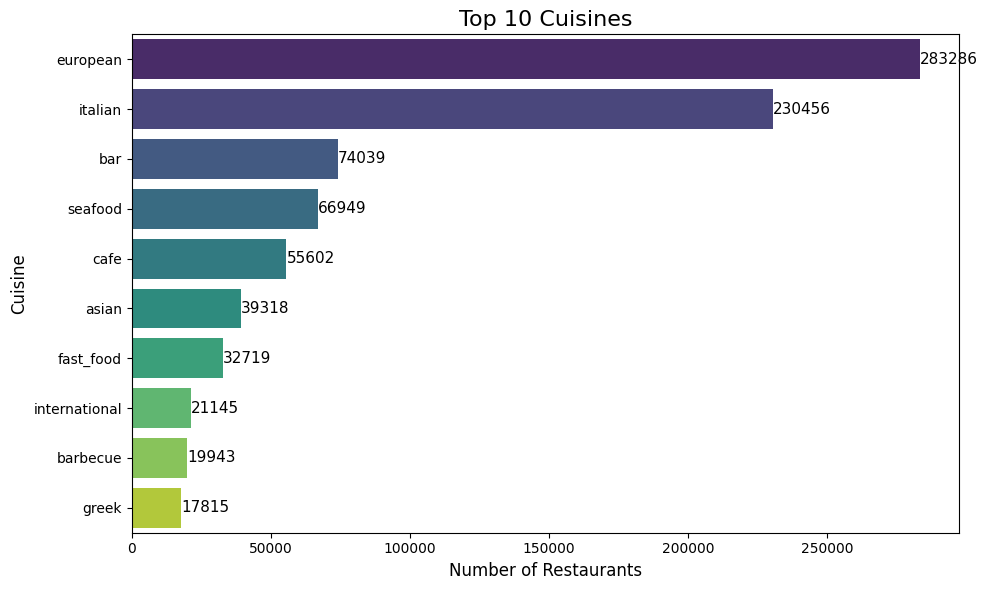

In [28]:
# Filter exploded dataframe to top 10 cuisines
exploded_top10 = exploded[exploded['cuisines_clean'].isin(top10)]

# Count the occurrences
cuisine_counts = exploded_top10['cuisines_clean'].value_counts().reindex(top10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cuisine_counts.values,
    y=cuisine_counts.index,
    palette='viridis'
)
plt.title('Top 10 Cuisines', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)

# Annotate counts
for i, v in enumerate(cuisine_counts.values):
    plt.text(v + 5, i, str(v), va='center', fontsize=11)

plt.tight_layout()
plt.show()

In [29]:
# Filter exploded dataframe to top 10 cuisines
exploded_top10 = exploded[exploded['cuisines_clean'].isin(top10)]

plt.figure(figsize=(12, 8))
sns.countplot(
    y='cuisines_clean',
    hue='price_level_cat',
    data=exploded_top10,
    order=top10[::-1],  # reverse for horizontal bars
    hue_order=['low', 'medium', 'high'],
    palette='coolwarm'
)
plt.title('Price Level Distribution for Top 10 Cuisines', fontsize=16)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Cuisine', fontsize=12)
plt.legend(title='Price Level', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `price_level_cat` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1200x800 with 0 Axes>

In [6]:
df['minimum_range'] = pd.to_numeric(df['price_range'].str.split('-').str[0].str.replace('€', '').str.replace(',', ''), errors='coerce')
df['maximum_range'] = pd.to_numeric(df['price_range'].str.split('-').str[1].str.replace('€', '').str.replace(',', ''), errors='coerce')
df['avg_price'] = (df['minimum_range'] + df['maximum_range']) / 2
#להוסיף משתנה של התפלגות (כמה רחב)
#יש בעיה עם המחירים - 75% הם עד איזה 40 , אבל יש כאן מחירים של 1000 ויותר

יצירת משתנה מטרה ומשתנה לחיזוי (כמה תגובות נתנו)

In [7]:
#כמות תגובות
df["total_reviews"] = df[["excellent", "very_good", "average", "poor", "terrible"]].sum(axis=1)
# there is a variable that is ready: total review count

In [ ]:
# משתנה ניבוי
df["Mean_rating"] = (
    df[["terrible", "poor", "average", "very_good", "excellent"]]
    .fillna(0)
    .mul([1, 2, 3, 4, 5])
    .sum(axis=1)
    .div(df["total_reviews"].replace(0, np.nan))
)
df["great_restaurant"] = df["Mean_rating"] > 3.5


In [9]:
df["great_restaurant"] = df["Mean_rating"] > 3.5

### missing values

In [4]:
df.isnull().sum()

restaurant_link                           0
restaurant_name                           1
original_location                         0
country                                   0
region                                50323
province                             340632
city                                 400685
address                                   0
latitude                              15790
longitude                             15790
claimed                                1842
awards                               820264
popularity_detailed                   94988
popularity_generic                    97792
top_tags                             110634
price_level                          277205
price_range                          779070
meals                                448050
cuisines                             169103
special_diets                        743141
features                             765990
vegetarian_friendly                       0
vegan_options                   

## working with missing values

### restaurant name

In [12]:
addr = df.loc[df['restaurant_name'].isna(), 'address'].iloc[0]
df[df['address'] == addr]

,restaurant_link,restaurant_name,original_location,country,region,province,city,address,latitude,longitude,...,excellent,very_good,average,poor,terrible,food,service,value,atmosphere,keywords
989060,g294454-d12637629,NaN,"[""Europe"", ""Croatia"", ""Central Croatia"", ""Zagr...",Croatia,Central Croatia,NaN,Zagreb,"Gramacha 2F, Zagreb 10000 Croatia",45.84642,15.94973,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


only this row - no other to copy the name from

### simple visualization

In [14]:
# --- Map price levels to categories ---
price_mapping = {
    '€': 'low',
    '€€-€€€': 'medium',
    '€€€€': 'high'
}
df['price_level_cat'] = df['price_level'].map(price_mapping)

# --- Extract only the first cuisine for multi-cuisine entries ---
df['first_cuisine'] = df['cuisines'].str.split(',', n=1).str[0]

# --- Summary info ---
num_restaurants = df['restaurant_link'].nunique()
num_countries = df['country'].nunique()
print(f'Total unique restaurants: {num_restaurants:,}')
print(f'Total unique countries: {num_countries}')


Total unique restaurants: 1,083,397
Total unique countries: 24


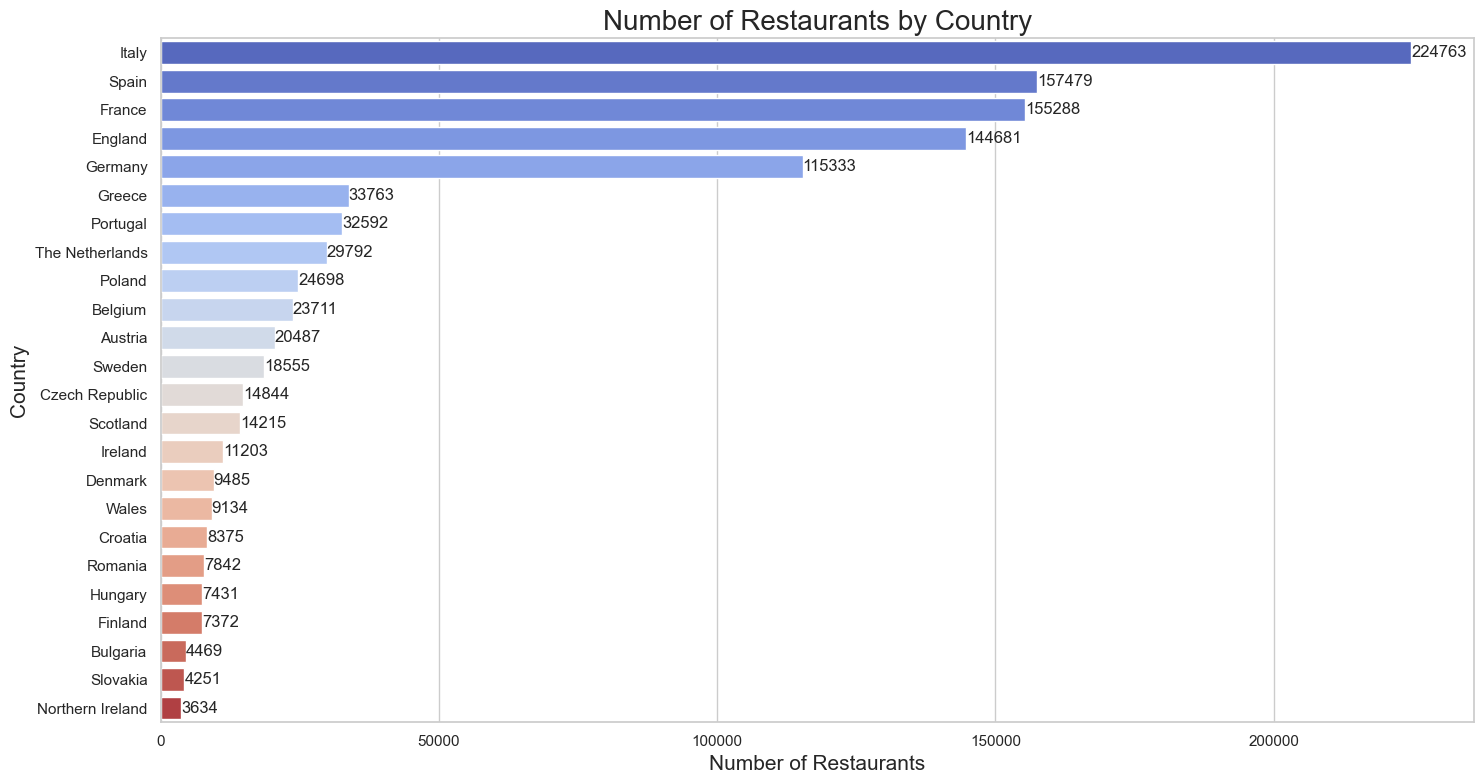

In [16]:

# --- Count restaurants per country ---
countries_count = df['country'].value_counts()

# --- Plot settings ---
sns.set_style('whitegrid')
plt.figure(figsize=(15, 8))
plt.title('Number of Restaurants by Country', fontsize=20)

# --- Horizontal barplot with palette mapped to countries ---
ax = sns.barplot(
    y=countries_count.index,
    x=countries_count.values,
    hue=countries_count.index,  # map palette to countries
    palette='coolwarm',
    dodge=False,
    legend=False  # hide legend since hue is only for colors
)

# --- Annotate counts on bars ---
for i, value in enumerate(countries_count.values):
    ax.text(value + 2, i, str(value), va='center', fontsize=12)

# --- Axis labels ---
plt.xlabel('Number of Restaurants', fontsize=15)
plt.ylabel('Country', fontsize=15)
plt.tight_layout()
plt.show()

## agregating data

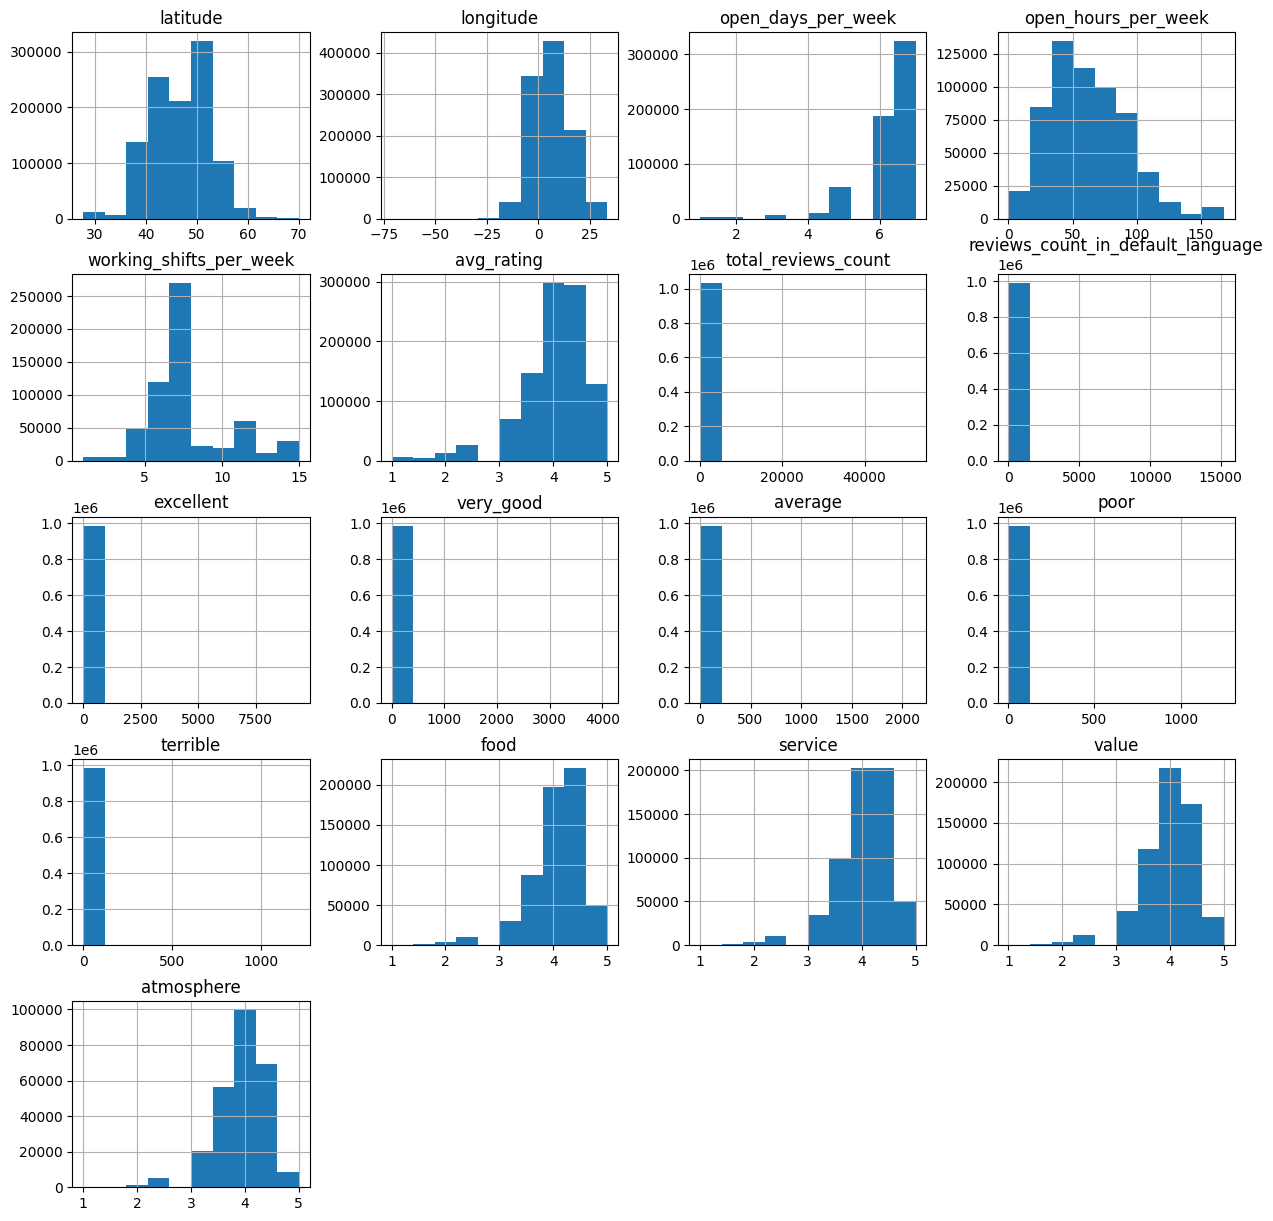

In [5]:
df.hist(figsize=(15, 15))
plt.show()

In [3]:
print(df['price_range'].value_counts())

price_range
€10-€30     5937
€5-€15      5810
€10-€20     5148
€5-€20      4793
€10-€25     4448
            ... 
€1-€406        1
€7-€157        1
€2-€142        1
€18-€81        1
€35-€180       1
Name: count, Length: 7298, dtype: int64


In [4]:
# Step 1: Extract the lower bound from the price range (e.g., '€10-€30' → 10)
df['price_range_lower'] = df['price_range'].str.extract(r'€(\d+)').astype(float)

# Define the bin edges and labels
bins = [float('-inf'), 20, 100, float('inf')]  # negative infinity to catch everything below 20
labels = ['Low', 'Medium', 'High']

# Use pd.cut to categorize
df['price_range_category'] = pd.cut(df['price_range_lower'], bins=bins, labels=labels)

# Optional: fill NaN with 'Unknown' for missing values
df['price_range_category'] = df['price_range_category'].cat.add_categories(['Unknown']).fillna('Unknown')

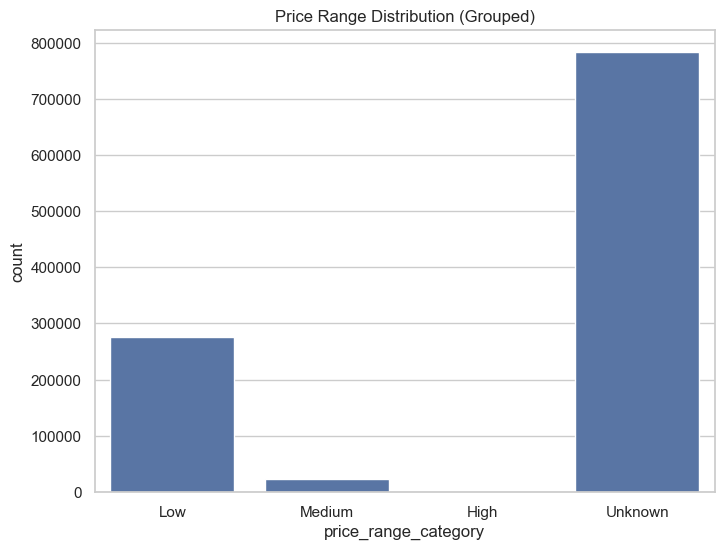

In [18]:
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range_category', data=df)
plt.title('Price Range Distribution (Grouped)')
plt.show()

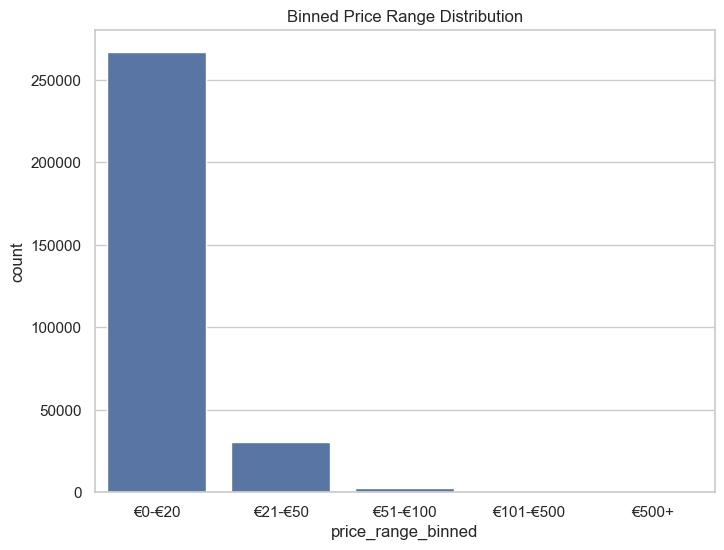

In [19]:
# Extract the lower bound of the price range as a float
df['price_range_lower'] = df['price_range'].str.extract(r'€(\d+)').astype(float)

# Define price bins (e.g., €0-€50, €51-€100, €101-€200, etc.)
bins = [0, 20, 50, 100, 500, 1000]
labels = ['€0-€20', '€21-€50', '€51-€100', '€101-€500', '€500+']

# Apply the bins to categorize the prices
df['price_range_binned'] = pd.cut(df['price_range_lower'], bins=bins, labels=labels, right=False)

# Plot the binned price ranges
plt.figure(figsize=(8, 6))
sns.countplot(x='price_range_binned', data=df)
plt.title('Binned Price Range Distribution')
plt.show()

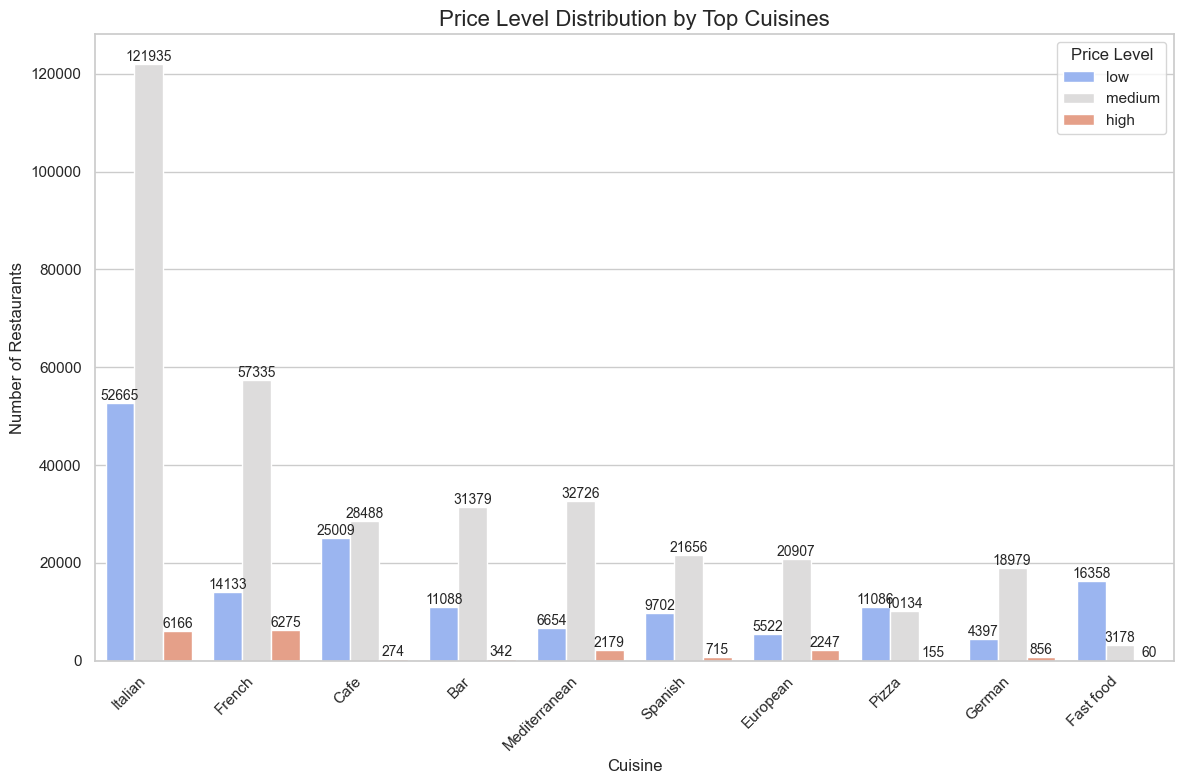

In [21]:
# --- Optional: limit to top 10 cuisines by count ---
top_cuisines = df['first_cuisine'].value_counts().nlargest(10).index
df_top_cuisines = df[df['first_cuisine'].isin(top_cuisines)]

# --- Plot ---
plt.figure(figsize=(12, 8))
sns.countplot(
    x='first_cuisine',
    hue='price_level_cat',
    data=df_top_cuisines,
    palette='coolwarm',
    order=top_cuisines,
    hue_order=['low', 'medium', 'high']
)

plt.title('Price Level Distribution by Top Cuisines', fontsize=16)
plt.xlabel('Cuisine', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.xticks(rotation=45, ha='right')

# --- Annotate counts on bars ---
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10)

plt.legend(title='Price Level', fontsize=11, title_fontsize=12)
plt.tight_layout()
plt.show()

country
Italy               224763
Spain               157479
France              155288
England             144681
Germany             115333
Greece               33763
Portugal             32592
The Netherlands      29792
Poland               24698
Belgium              23711
Austria              20487
Sweden               18555
Czech Republic       14844
Scotland             14215
Ireland              11203
Denmark               9485
Wales                 9134
Croatia               8375
Romania               7842
Hungary               7431
Finland               7372
Bulgaria              4469
Slovakia              4251
Northern Ireland      3634
Name: count, dtype: int64
cuisines
Italian           53243
French            39103
Cafe              35009
Spanish           27339
Italian, Pizza    26998
Name: count, dtype: int64


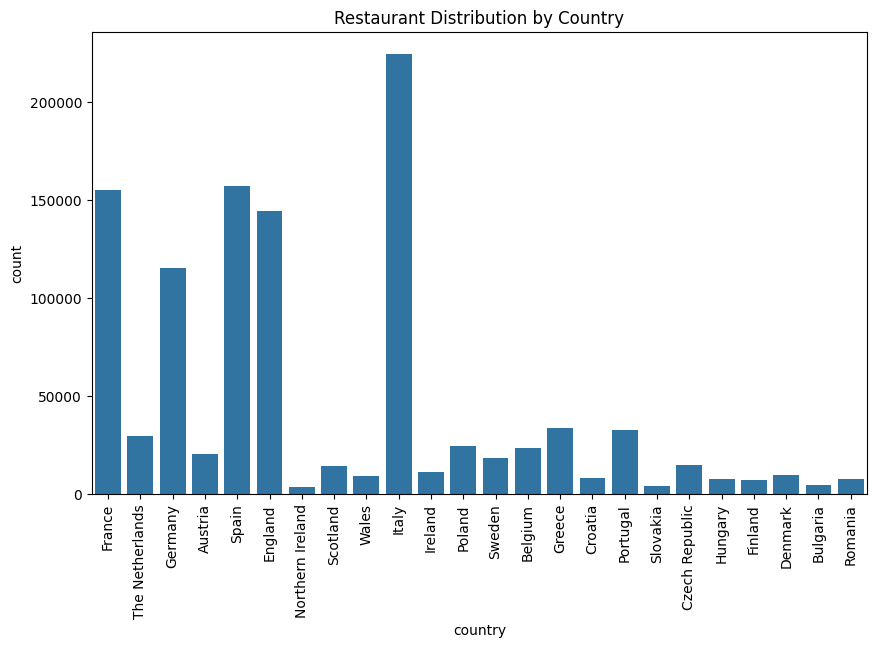

In [12]:
print(df['country'].value_counts())
print(df['cuisines'].value_counts().head())  # Check top cuisines

# Plot top countries
plt.figure(figsize=(10, 6))
sns.countplot(x='country', data=df)
plt.xticks(rotation=90)
plt.title('Restaurant Distribution by Country')
plt.show()

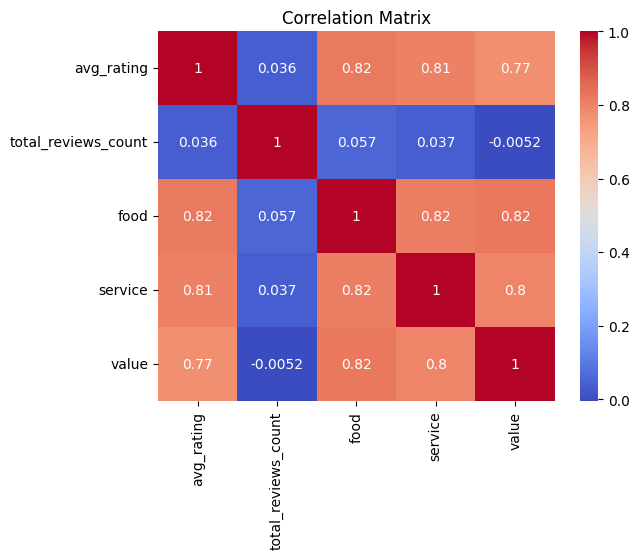

In [13]:
# Correlation heatmap
correlation_matrix = df[['avg_rating', 'total_reviews_count', 'food', 'service', 'value']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

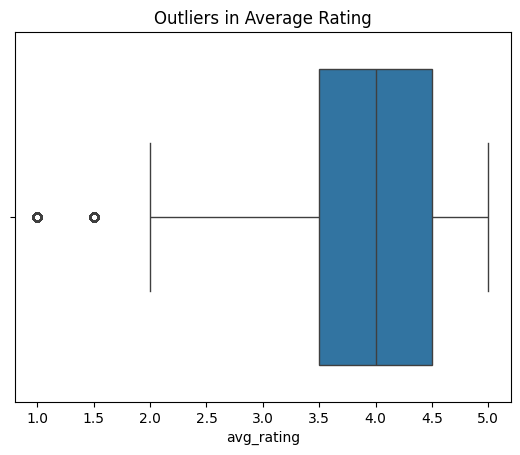

In [14]:
# Boxplot for outliers in ratings and review counts
sns.boxplot(x=df['avg_rating'])
plt.title('Outliers in Average Rating')
plt.show()

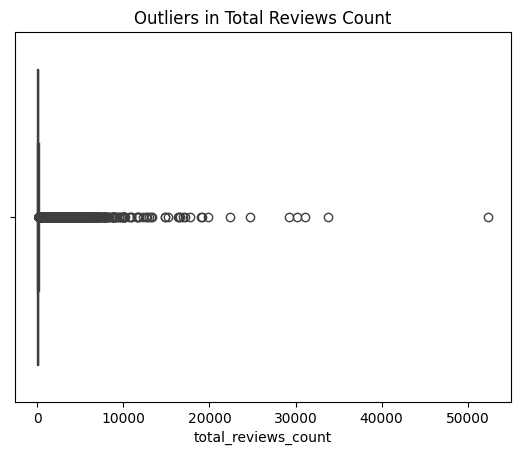

In [15]:
sns.boxplot(x=df['total_reviews_count'])
plt.title('Outliers in Total Reviews Count')
plt.show()